<a href="https://colab.research.google.com/github/yeattinbalasy/ML_Safe_Communication/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22PR3_%D0%91%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%89%D0%B5%D0%BD%D0%B8%D0%B5_%D0%A1%D0%BE%D0%B2%D0%B5%D1%82_%D0%A2%D0%B5%D0%BC%D0%B8%D1%80%D0%BB%D0%B0%D0%BD_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №3
## Разработка, обучение и сравнительный анализ моделей машинного обучения

**Предметная область:** интеллектуальная система безопасного общения  
**Задача:** бинарная классификация сообщений на безопасные и токсичные  
**Датасет:** Jigsaw Toxic Comment Classification Challenge  
**Модели:** Logistic Regression, Random Forest и Linear SVM

### Цель работы

Подготовить текстовые данные, обучить три модели классификации, оценить их с помощью
Accuracy, Precision, Recall, F1-score и ROC-AUC, визуализировать результаты и выбрать
наиболее эффективную модель для выявления токсичных сообщений.

Исходный Jigsaw содержит шесть меток нарушений. В этой работе они объединяются в одну
целевую переменную `is_toxic`: 0 — безопасное сообщение, 1 — токсичное сообщение.

In [ ]:
from pathlib import Path
import html
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Библиотеки подключены.")

Библиотеки подключены.


### 1. Загрузка данных

Поместите `jigsaw_toxic_30000.csv` рядом с ноутбуком. Если файл отсутствует и ноутбук
запущен в Google Colab, появится окно загрузки.

In [ ]:
DATA_PATH = Path("jigsaw_toxic_30000.csv")

if not DATA_PATH.exists():
    try:
        from google.colab import files
        print("Выберите файл jigsaw_toxic_30000.csv")
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded)))
    except ImportError as exc:
        raise FileNotFoundError(
            "Поместите jigsaw_toxic_30000.csv рядом с ноутбуком"
        ) from exc

df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print("Столбцы:", list(df.columns))
print(df.head(3).to_string(index=False))

Выберите файл jigsaw_toxic_30000.csv


Saving jigsaw_toxic_30000.csv to jigsaw_toxic_30000.csv
Размер датасета: 30,000 строк, 9 столбцов
Столбцы: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'is_toxic']
              id                                                                                                                                                                                                                                                                                                                       comment_text  toxic  severe_toxic  obscene  threat  insult  identity_hate  is_toxic
78691487e7ff2092 Formation of S constellations\nIs probably not to be attributed to Plancius, but according to Knobel, E. B. it must be attributed to Pieter Dirkszoon Keyser who \nformed all the southern constellations by measuring up most (or all) of their then known stars, specifically observe page 420 last sentence. ... said:  (bork²)      0             0        0     

### 2. Исследовательский анализ и проверка качества данных

In [ ]:
LABEL_COLUMNS = [
    "toxic", "severe_toxic", "obscene",
    "threat", "insult", "identity_hate"
]
required = {"id", "comment_text", "is_toxic", *LABEL_COLUMNS}
missing_columns = required - set(df.columns)
if missing_columns:
    raise ValueError(f"Отсутствуют обязательные столбцы: {sorted(missing_columns)}")

print("Пропущенные значения:")
print(df.isna().sum().to_string())
print("\nПолные дубликаты:", int(df.duplicated().sum()))
print("Дубликаты текста:", int(df.duplicated(subset=["comment_text"]).sum()))
print("\nРаспределение целевого класса:")
class_table = pd.DataFrame({
    "Количество": df["is_toxic"].value_counts().sort_index(),
    "Доля, %": (df["is_toxic"].value_counts(normalize=True).sort_index() * 100).round(2)
})
class_table.index = ["Безопасные (0)", "Токсичные (1)"]
print(class_table.to_string())

Пропущенные значения:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
is_toxic         0

Полные дубликаты: 0
Дубликаты текста: 0

Распределение целевого класса:
                Количество  Доля, %
Безопасные (0)       26950    89.83
Токсичные (1)         3050    10.17


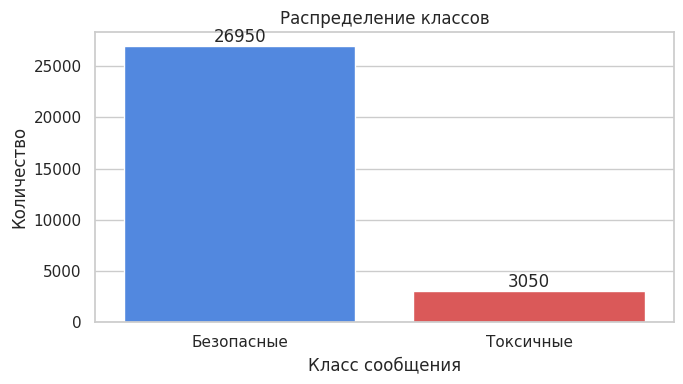

In [ ]:
class_counts = df["is_toxic"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=["Безопасные", "Токсичные"], y=class_counts.values,
                 palette=["#3B82F6", "#EF4444"])
ax.set_title("Распределение классов")
ax.set_xlabel("Класс сообщения")
ax.set_ylabel("Количество")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

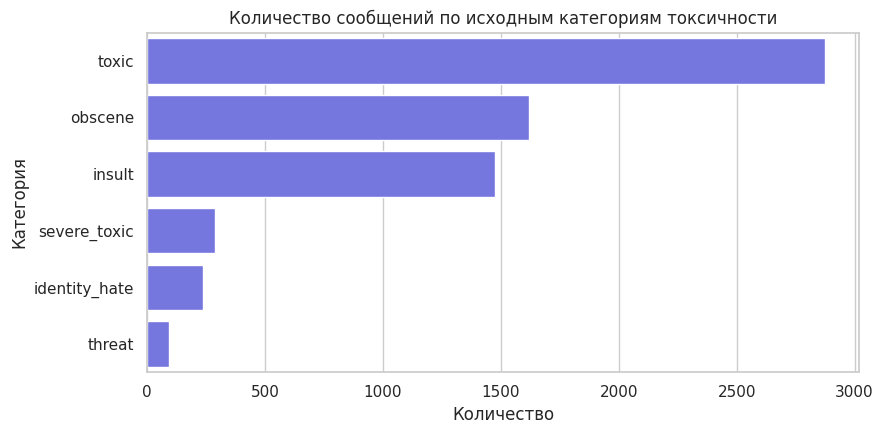

toxic            2874
obscene          1618
insult           1473
severe_toxic      289
identity_hate     237
threat             93


In [ ]:
label_counts = df[LABEL_COLUMNS].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=label_counts.values, y=label_counts.index, color="#6366F1")
ax.set_title("Количество сообщений по исходным категориям токсичности")
ax.set_xlabel("Количество")
ax.set_ylabel("Категория")
plt.tight_layout()
plt.savefig("toxic_categories.png", dpi=160, bbox_inches="tight")
plt.show()
print(label_counts.to_string())

### 3. Предобработка текста

Выполняется декодирование HTML, замена ссылок специальным токеном, приведение к
нижнему регистру и удаление лишних пробелов. Пропуски заменяются пустой строкой,
дубликаты текста удаляются.

In [ ]:
def clean_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

df = df.drop_duplicates(subset=["comment_text"]).copy()
df["comment_text"] = df["comment_text"].fillna("").map(clean_text)
df = df[df["comment_text"].str.len() > 0].reset_index(drop=True)
df["text_length"] = df["comment_text"].str.len()

print("Размер после предобработки:", df.shape)
print(df["text_length"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2).to_string())

Размер после предобработки: (30000, 10)
count    30000.00
mean       382.19
std        576.80
min          5.00
50%        198.00
90%        861.00
95%       1318.00
99%       3321.11
max       5000.00


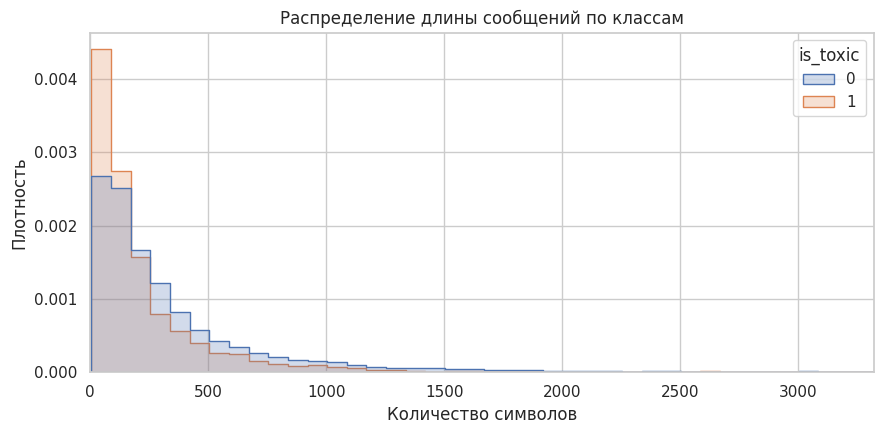

In [ ]:
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df, x="text_length", hue="is_toxic", bins=60,
             element="step", stat="density", common_norm=False)
plt.xlim(0, df["text_length"].quantile(0.99))
plt.title("Распределение длины сообщений по классам")
plt.xlabel("Количество символов")
plt.ylabel("Плотность")
plt.tight_layout()
plt.savefig("text_length_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### 4. Разделение данных и TF-IDF

Данные делятся в соотношении 80/20 со стратификацией. TF-IDF обучается только на
обучающей части, чтобы информация из тестовой выборки не влияла на обучение.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["comment_text"],
    df["is_toxic"].astype(int),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["is_toxic"]
)

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode"
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Обучающая выборка:", X_train.shape[0])
print("Тестовая выборка:", X_test.shape[0])
print("Размер матрицы TF-IDF:", X_train_tfidf.shape)

Обучающая выборка: 24000
Тестовая выборка: 6000
Размер матрицы TF-IDF: (24000, 20000)


### 5. Обучение моделей

Из-за дисбаланса классов используется параметр `class_weight`, повышающий значение
ошибок на токсичных сообщениях.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=4.0, class_weight="balanced",
        solver="liblinear", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=35, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Linear SVM": LinearSVC(
        C=1.0, class_weight="balanced", random_state=RANDOM_STATE
    )
}

results = []
predictions = {}
scores = {}
trained_models = {}

for name, model in models.items():
    started = time.perf_counter()
    model.fit(X_train_tfidf, y_train)
    train_time = time.perf_counter() - started

    started = time.perf_counter()
    y_pred = model.predict(X_test_tfidf)
    predict_time = time.perf_counter() - started

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    results.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Обучение, с": train_time,
        "Прогноз, с": predict_time
    })
    predictions[name] = y_pred
    scores[name] = y_score
    trained_models[name] = model
    print(f"{name}: обучение завершено за {train_time:.2f} с")

Logistic Regression: обучение завершено за 0.69 с
Random Forest: обучение завершено за 11.78 с
Linear SVM: обучение завершено за 0.72 с


### 6. Сравнение результатов

Главная метрика — F1-score токсичного класса. Она учитывает одновременно Precision
и Recall и лучше Accuracy отражает качество при несбалансированных классах.

In [ ]:
results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
print(results_df.round(4).to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)

best_model_name = results_df.loc[0, "Модель"]
print(f"\nЛучшая модель по F1-score: {best_model_name}")

             Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC  Обучение, с  Прогноз, с
Logistic Regression    0.9443     0.7117  0.7607    0.7353   0.9540       0.6872      0.0019
         Linear SVM    0.9453     0.7327  0.7279    0.7303   0.9495       0.7175      0.0025
      Random Forest    0.8653     0.3977  0.6311    0.4880   0.8580      11.7759      0.2746

Лучшая модель по F1-score: Logistic Regression


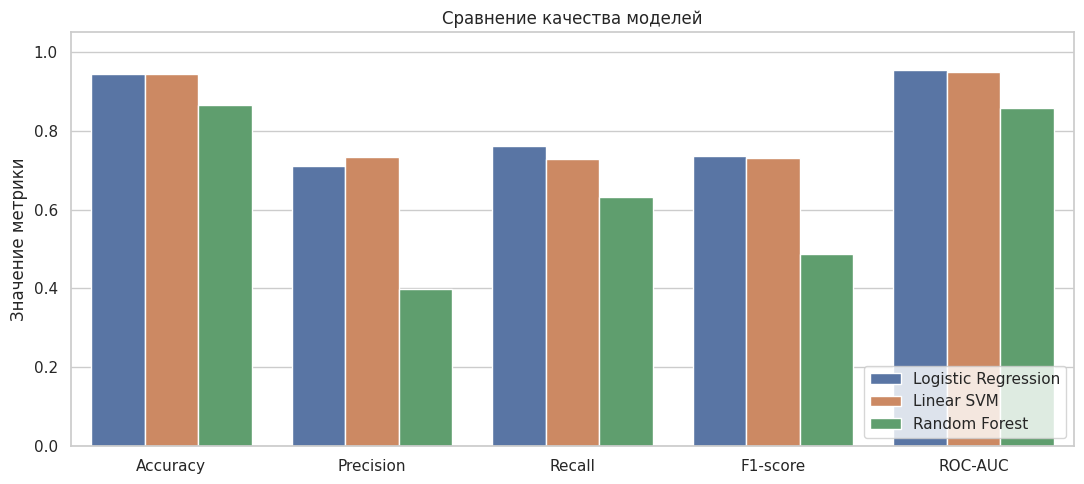

In [ ]:
plot_df = results_df.melt(
    id_vars="Модель", value_vars=metric_columns,
    var_name="Метрика", value_name="Значение"
)
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=plot_df, x="Метрика", y="Значение", hue="Модель")
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение качества моделей")
ax.set_xlabel("")
ax.set_ylabel("Значение метрики")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_metrics_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

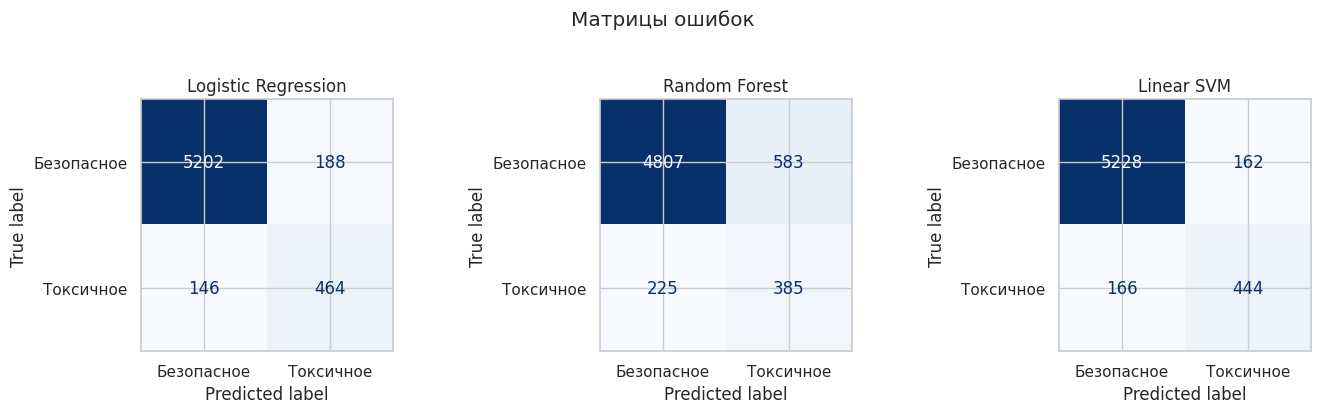

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Безопасное", "Токсичное"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d"
    )
    ax.set_title(name)
plt.suptitle("Матрицы ошибок", y=1.03)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=160, bbox_inches="tight")
plt.show()

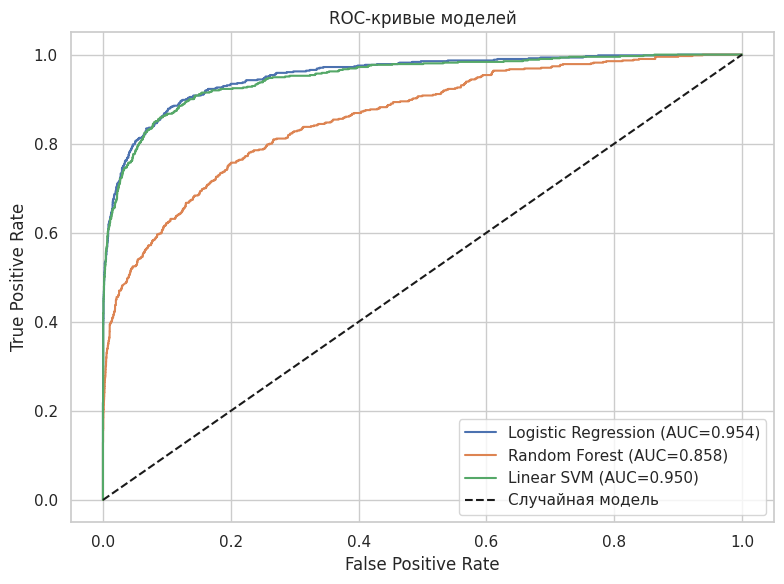

In [ ]:
plt.figure(figsize=(8, 6))
for name, y_score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Случайная модель")
plt.title("ROC-кривые моделей")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
for name, y_pred in predictions.items():
    print("=" * 70)
    print(name)
    print(classification_report(
        y_test, y_pred,
        target_names=["Безопасное", "Токсичное"],
        digits=4, zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

  Безопасное     0.9727    0.9651    0.9689      5390
   Токсичное     0.7117    0.7607    0.7353       610

    accuracy                         0.9443      6000
   macro avg     0.8422    0.8629    0.8521      6000
weighted avg     0.9462    0.9443    0.9452      6000

Random Forest
              precision    recall  f1-score   support

  Безопасное     0.9553    0.8918    0.9225      5390
   Токсичное     0.3977    0.6311    0.4880       610

    accuracy                         0.8653      6000
   macro avg     0.6765    0.7615    0.7052      6000
weighted avg     0.8986    0.8653    0.8783      6000

Linear SVM
              precision    recall  f1-score   support

  Безопасное     0.9692    0.9699    0.9696      5390
   Токсичное     0.7327    0.7279    0.7303       610

    accuracy                         0.9453      6000
   macro avg     0.8509    0.8489    0.8499      6000
weighted avg     0.9452    0.

### 7. Проверка на новых сообщениях

Датасет Jigsaw содержит английские комментарии, поэтому корректнее проверять модель
на английском тексте. Для русского языка нужен русскоязычный обучающий датасет.

In [ ]:
best_model = trained_models[best_model_name]

def predict_message(message):
    cleaned = clean_text(message)
    vector = vectorizer.transform([cleaned])
    prediction = int(best_model.predict(vector)[0])
    return "Токсичное" if prediction == 1 else "Безопасное"

examples = [
    "Thank you for your help with this article.",
    "You are stupid and disgusting.",
    "I will kill you.",
    "Please review my edits when you have time."
]
for message in examples:
    print(f"{predict_message(message):10} | {message}")

Безопасное | Thank you for your help with this article.
Токсичное  | You are stupid and disgusting.
Токсичное  | I will kill you.
Безопасное | Please review my edits when you have time.


### Вывод

В работе выполнены загрузка, исследовательский анализ и предобработка текстовых
данных. Сообщения преобразованы в TF-IDF-признаки, после чего обучены Logistic
Regression, Random Forest и Linear SVM. Модели сопоставлены по Accuracy, Precision,
Recall, F1-score, ROC-AUC, времени обучения и прогнозирования. Лучшей считается
модель с максимальным F1-score токсичного класса.

Ограничение исследования: Jigsaw является англоязычным датасетом. Для внедрения
модели в русскоязычную систему безопасного общения потребуется отдельный
русскоязычный размеченный набор данных или многоязычная модель.